# FINAL VERSION 2 — Generative AI & University Students
## Bibliometric + NLP + BERTopic + Social/Interpersonal Research-Gap Validation

### Research objective
Map how Generative AI research involving university students has evolved and test whether **social, interpersonal, communication, connectedness, and human–AI relational dimensions** are comparatively underrepresented.

### Important
This is a **literature-level secondary-data study**. It does not establish that Generative AI causes changes in individual students.

### Main improvement over V1
The social-gap analysis does **not** depend on the phrase “social interaction.” It combines:
- concept dictionaries,
- separate social semantic queries,
- BERTopic,
- temporal proportions,
- co-occurrence networks,
- and manual-validation candidates.

The notebook also imports the previously generated `Social_Semantic_Candidates.csv` if you have it.


In [ ]:
# 1. Install packages
!pip -q install pandas numpy matplotlib scikit-learn openpyxl sentence-transformers umap-learn hdbscan bertopic networkx nltk

import os, re, warnings, math, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

print("Environment ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 1.4 MB/s eta 0:00:00
Environment ready.


# 2. Upload files

Upload:
1. **Required:** `OpenAlex_GenerativeAI_Students_Cleaned.csv`
2. **Optional:** `Social_Semantic_Candidates.csv`

If you do not have the second file, simply upload the cleaned OpenAlex CSV.


In [ ]:
from google.colab import files

uploaded = files.upload()

csv_files = [f for f in uploaded if f.lower().endswith(".csv")]
if not csv_files:
    raise ValueError("Please upload at least the OpenAlex CSV.")

openalex_candidates = [
    f for f in csv_files
    if "openalex" in f.lower() or "cleaned" in f.lower()
]

OPENALEX_FILE = openalex_candidates[0] if openalex_candidates else csv_files[0]
social_candidate_files = [f for f in csv_files if "social" in f.lower()]

df = pd.read_csv(OPENALEX_FILE, low_memory=False)

print("OpenAlex file:", OPENALEX_FILE)
print("Shape:", df.shape)
print("Optional social candidates:", social_candidate_files)


Saving works-csv-HFVSQrUPA3cJb2N7qbb7nG.csv to works-csv-HFVSQrUPA3cJb2N7qbb7nG.csv
OpenAlex file: works-csv-HFVSQrUPA3cJb2N7qbb7nG.csv
Shape: (5008, 7)
Optional social candidates: []


In [ ]:
# 3. Normalize and detect columns

df.columns = [
    re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")
    for c in df.columns
]

def find_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

title_col = find_col(["title"])
abstract_col = find_col(["abstract", "abstracts"])
author_col = find_col(["author", "authors"])
year_col = find_col(["year", "publication_year"])
citation_col = find_col(["citation_count", "cited_by_count", "cited_by"])
doi_col = find_col(["doi"])
source_col = find_col(["source", "journal", "source_title"])

print({
    "title": title_col,
    "abstract": abstract_col,
    "authors": author_col,
    "year": year_col,
    "citations": citation_col,
    "doi": doi_col,
    "source": source_col
})

if not title_col or not abstract_col:
    raise ValueError("Title and Abstract columns are required.")


{'title': 'title', 'abstract': 'abstract', 'authors': 'author', 'year': 'year', 'citations': 'citation_count', 'doi': None, 'source': None}


# 4. Clean and deduplicate


In [ ]:
data = df.copy()

data = data[data[title_col].notna()].copy()
data[title_col] = data[title_col].astype(str).str.strip()
data[abstract_col] = data[abstract_col].fillna("").astype(str)

data["_title_norm"] = (
    data[title_col].str.lower()
    .str.replace(r"[^a-z0-9 ]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

before = len(data)
data = data.drop_duplicates("_title_norm", keep="first").copy()

if year_col:
    data[year_col] = pd.to_numeric(data[year_col], errors="coerce")

if citation_col:
    data["_citations"] = pd.to_numeric(data[citation_col], errors="coerce").fillna(0)

data["_text"] = (
    data[title_col].fillna("") + ". " + data[abstract_col].fillna("")
).str.strip()

print("Records before title deduplication:", before)
print("Unique records:", len(data))
print("Records with usable abstracts:", (data[abstract_col].str.len() >= 50).sum())


Records before title deduplication: 5008
Unique records: 4713
Records with usable abstracts: 3666


# 5. Dataset audit


In [ ]:
audit = pd.DataFrame({
    "metric": [
        "Initial records",
        "Unique records",
        "Duplicate titles removed",
        "Missing abstracts",
        "Usable abstracts (>=50 chars)",
        "Missing authors",
        "Missing year",
        "Missing citation count"
    ],
    "value": [
        len(df),
        len(data),
        before - len(data),
        int(data[abstract_col].str.len().eq(0).sum()),
        int((data[abstract_col].str.len() >= 50).sum()),
        int(data[author_col].isna().sum()) if author_col else np.nan,
        int(data[year_col].isna().sum()) if year_col else np.nan,
        int(data[citation_col].isna().sum()) if citation_col else np.nan
    ]
})

display(audit)


,metric,value
0,Initial records,5008
1,Unique records,4713
2,Duplicate titles removed,295
3,Missing abstracts,1044
4,Usable abstracts (>=50 chars),3666
5,Missing authors,31
6,Missing year,0
7,Missing citation count,0


# 6. Publication growth and citation profile


,year,publications
0,2022,4
1,2023,177
2,2024,656
3,2025,1615
4,2026,2261


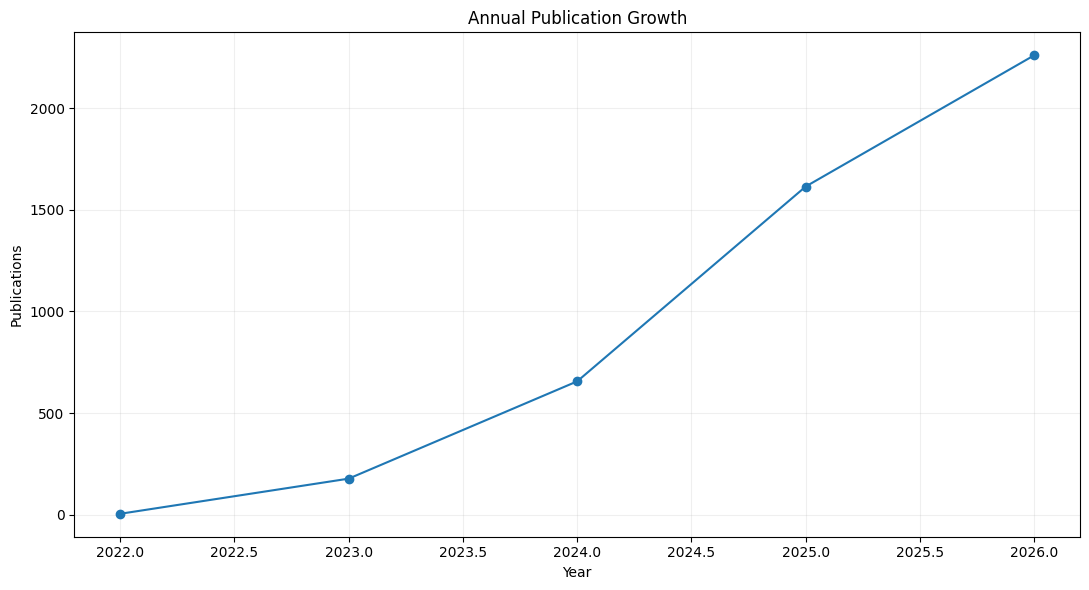

,title,author,year,citation_count
0,Students’ voices on generative AI: perceptions...,Cecilia Ka Yuk Chan|Wenjie Hu,2023,2186
1,The effect of generative artificial intelligen...,Ramazan Yılmaz|Fatma Gizem Karaoğlan Yılmaz,2023,718
2,Beware of metacognitive laziness: Effects of g...,Yizhou Fan|Luzhen Tang|Huixiao Le|Kejie Shen|S...,2024,634
3,Is it harmful or helpful? Examining the causes...,Muhammad Abbas|Farooq Ahmed Jam|Tariq Iqbal Khan,2024,468
4,Students’ Acceptance of ChatGPT in Higher Educ...,Artur Strzelecki,2023,430
5,To resist it or to embrace it? Examining ChatG...,Kai Guo|Deliang Wang,2023,416
6,Not quite eye to A.I.: student and teacher per...,Alex Barrett|Austin Pack,2023,366
7,Do you have AI dependency? The roles of academ...,Shunan Zhang|Xiangying Zhao|Tong Zhou|Jang Hyu...,2024,363
8,Impact of ChatGPT on ESL students’ academic wr...,Santosh Mahapatra,2024,356
9,Impact of Artificial Intelligence on Dental Ed...,Andrej Thurzo|Martin Strunga|Renáta Urban|Jana...,2023,347


In [ ]:
if year_col:
    annual = (
        data.dropna(subset=[year_col])
        .groupby(year_col)
        .size()
        .reset_index(name="publications")
    )
    annual[year_col] = annual[year_col].astype(int)
    annual = annual.sort_values(year_col)

    display(annual)

    plt.figure(figsize=(11,6))
    plt.plot(annual[year_col], annual["publications"], marker="o")
    plt.xlabel("Year")
    plt.ylabel("Publications")
    plt.title("Annual Publication Growth")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig("V2_annual_publication_growth.png", dpi=300, bbox_inches="tight")
    plt.show()

if citation_col:
    top_cited = data.sort_values("_citations", ascending=False).head(25)
    show = [c for c in [title_col, author_col, year_col, citation_col, source_col, doi_col] if c]
    display(top_cited[show].reset_index(drop=True))


# 7. Expanded concept dictionary

The social domain is deliberately divided into multiple constructs so that one keyword cannot dominate the conclusion.


In [ ]:
concepts = {
    "Education/Learning": [
        "education","learning","teaching","instruction","learning outcome",
        "pedagogy","higher education","classroom","student learning"
    ],
    "Adoption/Acceptance": [
        "acceptance","adoption","intention to use","technology acceptance",
        "behavioral intention","perceived usefulness","perceived ease of use"
    ],
    "Critical Thinking/Cognition": [
        "critical thinking","critical reasoning","reasoning","cognitive skill",
        "cognition","metacognition","higher order thinking","higher-order thinking",
        "problem solving","problem-solving","decision making","decision-making"
    ],
    "Creativity": [
        "creativity","creative thinking","creative problem solving",
        "creative problem-solving","originality","innovation"
    ],
    "AI Dependency": [
        "ai dependency","ai dependence","dependency on ai","dependence on ai",
        "reliance on ai","overreliance","over-reliance","automation bias"
    ],
    "Motivation/Engagement": [
        "motivation","engagement","self regulated learning",
        "self-regulated learning","academic engagement","learning motivation"
    ],
    "Psychological Well-being": [
        "anxiety","stress","fear","well-being","wellbeing","mental health",
        "confidence","self efficacy","self-efficacy","psychological"
    ],
    "Ethics/Integrity": [
        "academic integrity","plagiarism","academic dishonesty","cheating",
        "ethics","ethical","responsible ai","responsible artificial intelligence"
    ],
    "Privacy": [
        "privacy","data privacy","data protection","personal data","confidentiality"
    ],
    "Trust": [
        "trust in ai","trust in artificial intelligence","trustworthy ai",
        "trusting ai","trust"
    ],
    "Communication": [
        "communication","communicative","communication skills",
        "written communication","verbal communication","interpersonal communication"
    ],
    "Peer/Social Interaction": [
        "social interaction","peer interaction","peer relationship",
        "peer relationships","student collaboration","group interaction",
        "social behavior","social behaviour","classroom interaction",
        "peer collaboration","student interaction"
    ],
    "Interpersonal Relationships": [
        "interpersonal","interpersonal relationship","interpersonal relationships",
        "human relationship","human relationships","face to face",
        "face-to-face","person to person","human interaction"
    ],
    "Social Connectedness/Isolation": [
        "social connectedness","social connection","sense of belonging",
        "social isolation","social withdrawal","loneliness","lonely",
        "belongingness","social support"
    ],
    "Human-AI Relationship": [
        "ai companionship","artificial intelligence companionship",
        "emotional attachment","anthropomorphism","social presence",
        "human ai relationship","human-ai relationship","relational interaction",
        "emotional connection with ai"
    ]
}

def concept_mask(series, terms):
    escaped = [re.escape(t).replace(r"\ ", r"\s+") for t in terms]
    pattern = r"(?:" + "|".join(escaped) + r")"
    return series.str.contains(pattern, case=False, regex=True, na=False)

rows = []
for concept, terms in concepts.items():
    m = concept_mask(data["_text"], terms)
    rows.append({
        "concept": concept,
        "papers": int(m.sum()),
        "percentage": round(m.mean()*100, 3)
    })

concept_table = pd.DataFrame(rows).sort_values("papers", ascending=False)
display(concept_table)


,concept,papers,percentage
0,Education/Learning,3769,79.970
7,Ethics/Integrity,1315,27.902
5,Motivation/Engagement,1219,25.865
2,Critical Thinking/Cognition,1066,22.618
1,Adoption/Acceptance,1031,21.876
6,Psychological Well-being,880,18.672
3,Creativity,573,12.158
4,AI Dependency,444,9.421
10,Communication,316,6.705
9,Trust,287,6.090


# 8. Five-dimensional research landscape


,dimension,papers,percentage
0,Educational/Adoption,3879,82.304
3,Psychological/Ethical,2049,43.475
2,Behavioral,1479,31.381
1,Cognitive,1402,29.748
4,Social/Relational,470,9.972


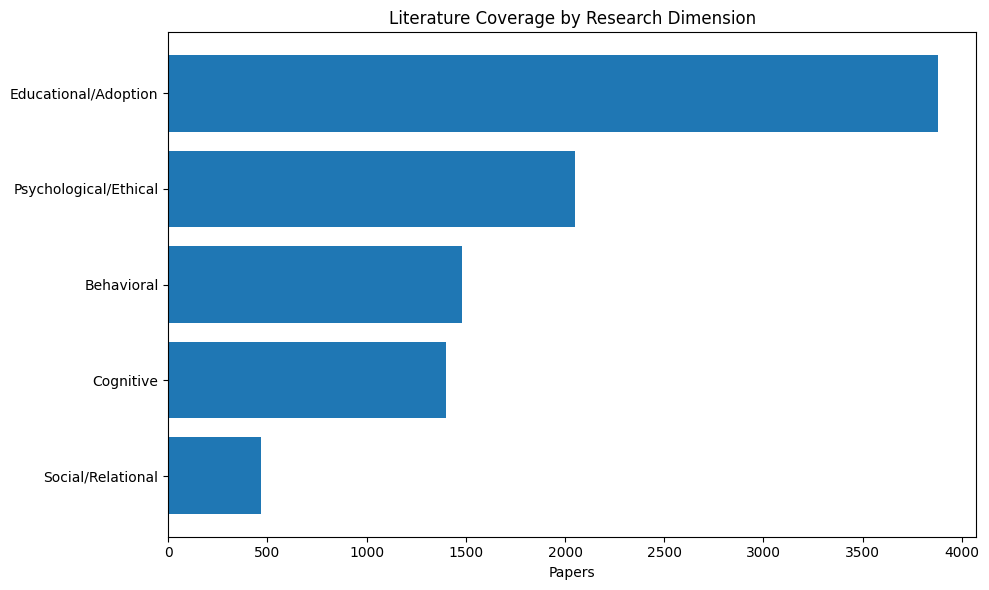

In [ ]:
dimension_map = {
    "Educational/Adoption": ["Education/Learning","Adoption/Acceptance"],
    "Cognitive": ["Critical Thinking/Cognition","Creativity"],
    "Behavioral": ["AI Dependency","Motivation/Engagement"],
    "Psychological/Ethical": ["Psychological Well-being","Trust","Ethics/Integrity","Privacy"],
    "Social/Relational": [
        "Communication","Peer/Social Interaction","Interpersonal Relationships",
        "Social Connectedness/Isolation","Human-AI Relationship"
    ]
}

dimension_rows = []
for dimension, subs in dimension_map.items():
    combined = pd.Series(False, index=data.index)
    for sub in subs:
        combined = combined | concept_mask(data["_text"], concepts[sub])
    dimension_rows.append({
        "dimension": dimension,
        "papers": int(combined.sum()),
        "percentage": round(combined.mean()*100, 3)
    })

dimension_table = pd.DataFrame(dimension_rows).sort_values("papers", ascending=False)
display(dimension_table)

plt.figure(figsize=(10,6))
p = dimension_table.sort_values("papers")
plt.barh(p["dimension"], p["papers"])
plt.xlabel("Papers")
plt.title("Literature Coverage by Research Dimension")
plt.tight_layout()
plt.savefig("V2_dimension_coverage.png", dpi=300, bbox_inches="tight")
plt.show()


# 9. Temporal concept analysis

Because the literature grows rapidly, **percentage of papers per year** is more informative than raw counts.


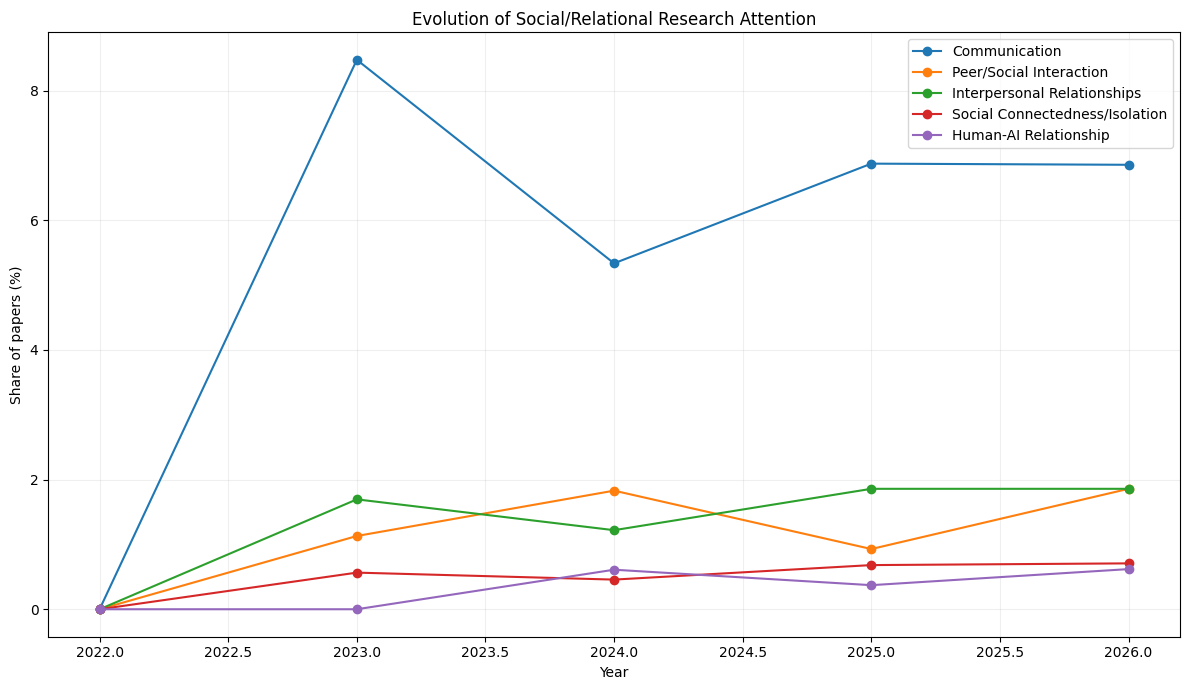

concept,Communication,Human-AI Relationship,Interpersonal Relationships,Peer/Social Interaction,Social Connectedness/Isolation
year,,,,,
2022,0.000,0.000,0.000,0.000,0.000
2023,8.475,0.000,1.695,1.130,0.565
2024,5.335,0.610,1.220,1.829,0.457
2025,6.873,0.372,1.858,0.929,0.681
2026,6.855,0.619,1.858,1.858,0.708


In [ ]:
if year_col:
    temporal_rows = []

    for concept, terms in concepts.items():
        m = concept_mask(data["_text"], terms)
        tmp = pd.DataFrame({"year": data[year_col], "match": m.astype(int)}).dropna()
        g = tmp.groupby("year").agg(
            total=("match","size"),
            papers=("match","sum")
        ).reset_index()
        g["percentage"] = g["papers"] / g["total"] * 100
        g["concept"] = concept
        temporal_rows.append(g)

    temporal = pd.concat(temporal_rows, ignore_index=True)
    temporal["year"] = temporal["year"].astype(int)

    social = [
        "Communication","Peer/Social Interaction","Interpersonal Relationships",
        "Social Connectedness/Isolation","Human-AI Relationship"
    ]

    plt.figure(figsize=(12,7))
    for c in social:
        s = temporal[temporal["concept"] == c]
        plt.plot(s["year"], s["percentage"], marker="o", label=c)

    plt.xlabel("Year")
    plt.ylabel("Share of papers (%)")
    plt.title("Evolution of Social/Relational Research Attention")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig("V2_social_temporal_evolution.png", dpi=300, bbox_inches="tight")
    plt.show()

    display(
        temporal[temporal["concept"].isin(social)]
        .pivot(index="year", columns="concept", values="percentage")
        .round(3)
    )


# 10. TF-IDF


In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    max_features=8000
)

X_tfidf = tfidf.fit_transform(data["_text"])
terms = np.array(tfidf.get_feature_names_out())
scores = np.asarray(X_tfidf.mean(axis=0)).ravel()

tfidf_table = (
    pd.DataFrame({"term": terms, "tfidf_mean": scores})
    .sort_values("tfidf_mean", ascending=False)
    .head(75)
)

display(tfidf_table)


,term,tfidf_mean
403,ai,0.065634
6696,students,0.052451
1168,chatgpt,0.044190
4132,learning,0.035989
6887,study,0.030109
...,...,...
1736,course,0.009027
234,acceptance,0.008914
4029,knowledge,0.008907
5276,potential,0.008906


# 11. LDA topic modeling


In [ ]:
count_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=8,
    max_df=0.90,
    max_features=10000
)

X_count = count_vectorizer.fit_transform(data["_text"])
feature_names = count_vectorizer.get_feature_names_out()

from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS = 10
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=40
)

lda_doc_topic = lda.fit_transform(X_count)

lda_rows = []
for i, topic in enumerate(lda.components_):
    idx = topic.argsort()[:-16:-1]
    lda_rows.append({
        "topic": i+1,
        "top_words": ", ".join(feature_names[idx])
    })

lda_topics = pd.DataFrame(lda_rows)
display(lda_topics)

data["lda_topic"] = lda_doc_topic.argmax(axis=1) + 1
lda_distribution = data["lda_topic"].value_counts().sort_index()
display(lda_distribution.to_frame("papers"))


,topic,top_words
0,1,"ai, students, generative, intelligence, artifi..."
1,2,"perceived, genai, use, students, acceptance, m..."
2,3,"chatgpt, students, study, use, academic, tools..."
3,4,"chatgpt, medical, ai, models, generated, stude..."
4,5,"ai, students, use, academic, generative, unive..."
5,6,"ai, genai, students, critical, generative, thi..."
6,7,"writing, ai, language, english, feedback, stud..."
7,8,"research, work, use, al, et, review, la, et al..."
8,9,"group, experimental, learning, chatgpt, test, ..."
9,10,"learning, ai, education, tools, engagement, ed..."


,papers
lda_topic,
1,730
2,430
3,894
4,399
5,389
6,766
7,650
8,88
9,178


# 12. BERTopic semantic analysis

This is the main semantic topic model. It can identify conceptually similar papers even when they use different vocabulary.


In [ ]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

texts = data["_text"].tolist()

embeddings = embedding_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embeddings:", embeddings.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/148 [00:00<?, ?it/s]

Embeddings: (4713, 384)


In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=30,
    nr_topics="auto",
    calculate_probabilities=True,
    verbose=True
)

bertopic_topics, bertopic_probs = topic_model.fit_transform(
    texts, embeddings
)

data["bertopic_topic"] = bertopic_topics

bertopic_info = topic_model.get_topic_info()
display(bertopic_info.head(30))


2026-09-14 03:22:15,554 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-14 03:23:01,003 - BERTopic - Dimensionality - Completed ✓
2026-09-14 03:23:01,005 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-14 03:23:01,530 - BERTopic - Cluster - Completed ✓
2026-09-14 03:23:01,532 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-14 03:23:02,555 - BERTopic - Representation - Completed ✓
2026-09-14 03:23:02,557 - BERTopic - Topic reduction - Reducing number of topics
2026-09-14 03:23:02,571 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-14 03:23:03,566 - BERTopic - Representation - Completed ✓
2026-09-14 03:23:03,570 - BERTopic - Topic reduction - Reduced number of topics from 21 to 21


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1656,-1_the_and_of_in,"[the, and, of, in, ai, to, students, for, with...",[Ethical challenges of artificial intelligence...
1,0,592,0_writing_the_and_feedback,"[writing, the, and, feedback, in, of, ai, stud...",[Enhancing College Learners' Writing Skills th...
2,1,426,1_and_medical_the_of,"[and, medical, the, of, in, to, for, clinical,...",[Comparing ChatGPT and Dental Students' Perfor...
3,2,280,2_language_the_and_english,"[language, the, and, english, of, in, learning...",[AI-Assisted Language Learning: The Influence ...
4,3,197,3_chatgpt_the_of_and,"[chatgpt, the, of, and, use, students, to, in,...",[Factors Influencing ChatGPT Utilisation in Hi...
5,4,177,4_programming_the_and_in,"[programming, the, and, in, to, of, learning, ...",[The effect of generative artificial intellige...
6,5,171,5_intention_the_and_of,"[intention, the, and, of, acceptance, perceive...",[Factors Influencing University Students' Adop...
7,6,168,6_creative_design_creativity_and,"[creative, design, creativity, and, the, ai, i...","[Expert Eyes, Machine Hands. Introduction Gene..."
8,7,134,7_self_and_ai_learning,"[self, and, ai, learning, the, generative, of,...",[Exploring the relationship between artificial...
9,8,130,8_chatgpt_university_of_students,"[chatgpt, university, of, students, on, in, an...",[University Students’ Perceptions of ChatGPT U...


In [ ]:
bertopic_words = []

for topic_id in bertopic_info["Topic"]:
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    if words:
        bertopic_words.append({
            "topic": topic_id,
            "top_words": ", ".join([w for w, s in words[:15]])
        })

bertopic_words = pd.DataFrame(bertopic_words)
display(bertopic_words)


,topic,top_words
0,0,"writing, the, and, feedback, in, of, ai, stude..."
1,1,"and, medical, the, of, in, to, for, clinical, ..."
2,2,"language, the, and, english, of, in, learning,..."
3,3,"chatgpt, the, of, and, use, students, to, in, ..."
4,4,"programming, the, and, in, to, of, learning, s..."
5,5,"intention, the, and, of, acceptance, perceived..."
6,6,"creative, design, creativity, and, the, ai, in..."
7,7,"self, and, ai, learning, the, generative, of, ..."
8,8,"chatgpt, university, of, students, on, in, and..."
9,9,"ethical, and, ai, of, academic, students, the,..."


# 13. Social semantic analysis — corrected version

We use **five independent queries** instead of one broad query.

This is specifically designed to avoid the V1 problem where generic "student/ChatGPT perception" papers dominated the results.


In [ ]:
social_queries = {
    "Peer interaction": (
        "university students peer interaction peer relationships "
        "student collaboration group interaction classroom interaction"
    ),
    "Interpersonal communication": (
        "university students interpersonal communication human communication "
        "face to face communication communication skills relationships"
    ),
    "Social connectedness": (
        "university students social connectedness belonging loneliness "
        "social isolation social withdrawal social support"
    ),
    "Human-AI relationship": (
        "human AI relationship AI companionship emotional attachment "
        "anthropomorphism social presence relational interaction"
    ),
    "Social behavior": (
        "university students social behavior interpersonal behavior "
        "relationship behavior social conduct human interaction"
    )
}

query_embeddings = embedding_model.encode(
    list(social_queries.values()),
    normalize_embeddings=True
)

social_sim_matrix = cosine_similarity(query_embeddings, embeddings)

for i, name in enumerate(social_queries):
    safe = re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")
    data[f"sim_{safe}"] = social_sim_matrix[i]

sim_cols = [c for c in data.columns if c.startswith("sim_")]

data["social_max_similarity"] = data[sim_cols].max(axis=1)
data["social_mean_similarity"] = data[sim_cols].mean(axis=1)

social_candidates_v2 = data.sort_values(
    ["social_max_similarity","social_mean_similarity"],
    ascending=False
).head(300).copy()

display(
    social_candidates_v2[
        [c for c in [title_col, year_col, author_col, abstract_col, doi_col] if c]
        + sim_cols
        + ["social_max_similarity","social_mean_similarity"]
    ].head(50)
)


,title,year,author,abstract,sim_peer_interaction,sim_interpersonal_communication,sim_social_connectedness,sim_human_ai_relationship,sim_social_behavior,social_max_similarity,social_mean_similarity
3730,When Machines Become Listeners: Emotional Inti...,2026,Christy Gabriella Hutagalung|Ilyas Dzaky Almah...,The rapid integration of Artificial Intelligen...,0.231286,0.373747,0.272045,0.642245,0.233367,0.642245,0.350538
3670,The evaluation of AI companions relative to fa...,2026,Cindy H. Liu|Jiawei Wu|Angela Zhao|Lijuan Wang...,Background Generative AI is increasingly used ...,0.188720,0.316524,0.421416,0.640795,0.326083,0.640795,0.378708
4956,A Three-Layered Framework and Measurement Tool...,2026,Chuqi Chen|Huiguang Ren|Junsheng Liu|Fangfang ...,As generative artificial intelligence (AI) bec...,0.229677,0.334782,0.291115,0.609948,0.305553,0.609948,0.354215
3323,TALKING TO MACHINES: A CORRELATIONAL STUDY OF ...,2026,SILLA JACOB 1 MANJULIKA KARMAKAR 2 JUHI SOLAMA...,Abstract: The increasing use of AI chatbots ha...,0.211419,0.370479,0.230266,0.599873,0.270082,0.599873,0.336424
463,Can interaction with generative artificial int...,2024,Zehang Xie|Xinzhu Wu|Yunxiang Xie,Abstract Background With the development of ar...,0.348269,0.357540,0.220576,0.582209,0.319467,0.582209,0.365612
1870,The Double-Edged Sword Effect of Interaction F...,2025,Wenyan Sun|Zhanfeng Jiang|Shenyang Hai,Generative artificial intelligence (AI) has be...,0.394504,0.408257,0.560419,0.523073,0.479688,0.560419,0.473188
4504,A Q Methodological Study on Algorithmic Intima...,2026,Kyoung Yeon Moon|Taeeun Shim,This study explores how university students ex...,0.342705,0.445863,0.274800,0.551799,0.322080,0.551799,0.387449
2548,The impact of loneliness on university student...,2026,Mingyue Cui|Xi Chen|Pu Sun|Ke Ma|Xiaohong Xu|L...,,0.254243,0.338685,0.542728,0.494364,0.275688,0.542728,0.381142
1736,Artificial Intimacy and Human Connection: A Co...,2025,Angelita Damilig|Anna Leigh Botones,This qualitative study explores the lived expe...,0.370862,0.486990,0.399206,0.542040,0.396761,0.542040,0.439172
3302,Enhancing Software Engineering Education throu...,2026,MinSuk Lee,This empirical investigation delves into the i...,0.531391,0.281562,0.205506,0.114018,0.246740,0.531391,0.275843


# 14. Social Research Index

The index is a transparent screening device, **not a validated psychological scale**.

It combines:
- explicit social terminology,
- semantic social similarity,
- and the breadth of social dimensions represented.


In [17]:
social_concepts = [
    "Communication",
    "Peer/Social Interaction",
    "Interpersonal Relationships",
    "Social Connectedness/Isolation",
    "Human-AI Relationship"
]

# Create binary flags for each social concept
social_flags = []

for c in social_concepts:
    flag = concept_mask(data["_text"], concepts[c]).astype(int)
    social_flags.append(flag)

# Combine flags
social_flag_matrix = pd.concat(social_flags, axis=1)
social_flag_matrix.columns = social_concepts

# IMPORTANT:
# Add the social concept columns to the main data frame
for c in social_concepts:
    data[c] = social_flag_matrix[c]

# Count how many different social dimensions each paper contains
data["social_concept_count"] = social_flag_matrix.sum(axis=1)

# Explicit lexical social indicator
data["social_lexical_flag"] = (
    data["social_concept_count"] >= 1
).astype(int)

# Semantic percentile
data["social_semantic_percentile"] = (
    data["social_max_similarity"].rank(pct=True)
)

# Breadth across the five social dimensions
data["social_breadth"] = (
    data["social_concept_count"] / len(social_concepts)
).clip(0, 1)

# Combined Social Research Index
data["social_research_index"] = (
    35 * data["social_lexical_flag"]
    + 45 * data["social_semantic_percentile"]
    + 20 * data["social_breadth"]
)

# Display top 50 social-relevant papers
display_cols = [
    c for c in [
        title_col,
        year_col,
        author_col,
        abstract_col
    ]
    if c
]

display_cols += social_concepts

display_cols += [
    "social_concept_count",
    "social_semantic_percentile",
    "social_breadth",
    "social_research_index"
]

result_social = (
    data
    .sort_values(
        "social_research_index",
        ascending=False
    )
    [display_cols]
    .head(50)
)

display(result_social)

,title,year,author,abstract,Communication,Peer/Social Interaction,Interpersonal Relationships,Social Connectedness/Isolation,Human-AI Relationship,social_concept_count,social_semantic_percentile,social_breadth,social_research_index
4367,Determinants of GenAI-Supported Experiential L...,2026,Nualyai Pitsachart|Vitsanu Nittayathammakul|Te...,Generative artificial intelligence (GenAI) is ...,1,1,1,1,0,4,0.931254,0.8,92.906429
4504,A Q Methodological Study on Algorithmic Intima...,2026,Kyoung Yeon Moon|Taeeun Shim,This study explores how university students ex...,0,0,1,1,1,3,0.998727,0.6,91.942712
3866,Combining analog and digital approaches to stu...,2026,Michael Barr|Brian Bachman|Alexander Carroll,This paper describes findings from a study tha...,1,1,1,0,0,3,0.997242,0.6,91.875875
2597,The Influence of Artificial Intelligence on In...,2026,Vimala a/p Govindaraju|Elly Illya Arissa,This study explores the influence of Artificia...,1,1,1,0,0,3,0.996817,0.6,91.856779
4405,"Beyond academic use: Emotional reliance, socia...",2026,Anas Alhur|Badr Alnasser,Background: Conversational artificial intellig...,0,1,1,1,0,3,0.987481,0.6,91.436665
3323,TALKING TO MACHINES: A CORRELATIONAL STUDY OF ...,2026,SILLA JACOB 1 MANJULIKA KARMAKAR 2 JUHI SOLAMA...,Abstract: The increasing use of AI chatbots ha...,1,0,0,0,1,2,0.999363,0.4,87.971356
1870,The Double-Edged Sword Effect of Interaction F...,2025,Wenyan Sun|Zhanfeng Jiang|Shenyang Hai,Generative artificial intelligence (AI) has be...,0,1,0,1,0,2,0.998939,0.4,87.952260
1736,Artificial Intimacy and Human Connection: A Co...,2025,Angelita Damilig|Anna Leigh Botones,This qualitative study explores the lived expe...,0,0,1,0,1,2,0.998303,0.4,87.923616
311,When artificial intelligence substitutes human...,2024,Joseph Crawford|Kelly‐Ann Allen|Bianca Pani|Mi...,Artificial intelligence (AI) may be the new-ne...,0,1,0,1,0,2,0.997029,0.4,87.866327
2820,THE EFFECTIVENESS OF INTERACTIVE METHODS IN DE...,2026,Tetiana Tryhobiuk,The article examines the effectiveness of inte...,1,1,0,0,0,2,0.990876,0.4,87.589433


# 15. Test whether the apparent social gap persists

We compare explicit lexical social evidence with the semantic tail.

**Important:** The semantic threshold is a screening threshold, not a claim that the top 10% are "social papers."


In [18]:
social_lexical = data["social_lexical_flag"].astype(bool)
semantic_90 = data["social_max_similarity"].quantile(0.90)
semantic_top10 = data["social_max_similarity"] >= semantic_90

combined_social = social_lexical | semantic_top10

gap_test = pd.DataFrame({
    "screen": [
        "Explicit social terminology",
        "Top 10% semantic social similarity",
        "Either explicit OR semantic screen"
    ],
    "papers": [
        int(social_lexical.sum()),
        int(semantic_top10.sum()),
        int(combined_social.sum())
    ],
    "percentage": [
        round(social_lexical.mean()*100, 2),
        round(semantic_top10.mean()*100, 2),
        round(combined_social.mean()*100, 2)
    ]
})

display(gap_test)

print("90th percentile semantic threshold:", round(float(semantic_90), 4))


,screen,papers,percentage
0,Explicit social terminology,470,9.97
1,Top 10% semantic social similarity,472,10.01
2,Either explicit OR semantic screen,816,17.31


90th percentile semantic threshold: 0.3821


# 16. Social concept co-occurrence network


Social concept nodes: 5
Social concept edges: 8


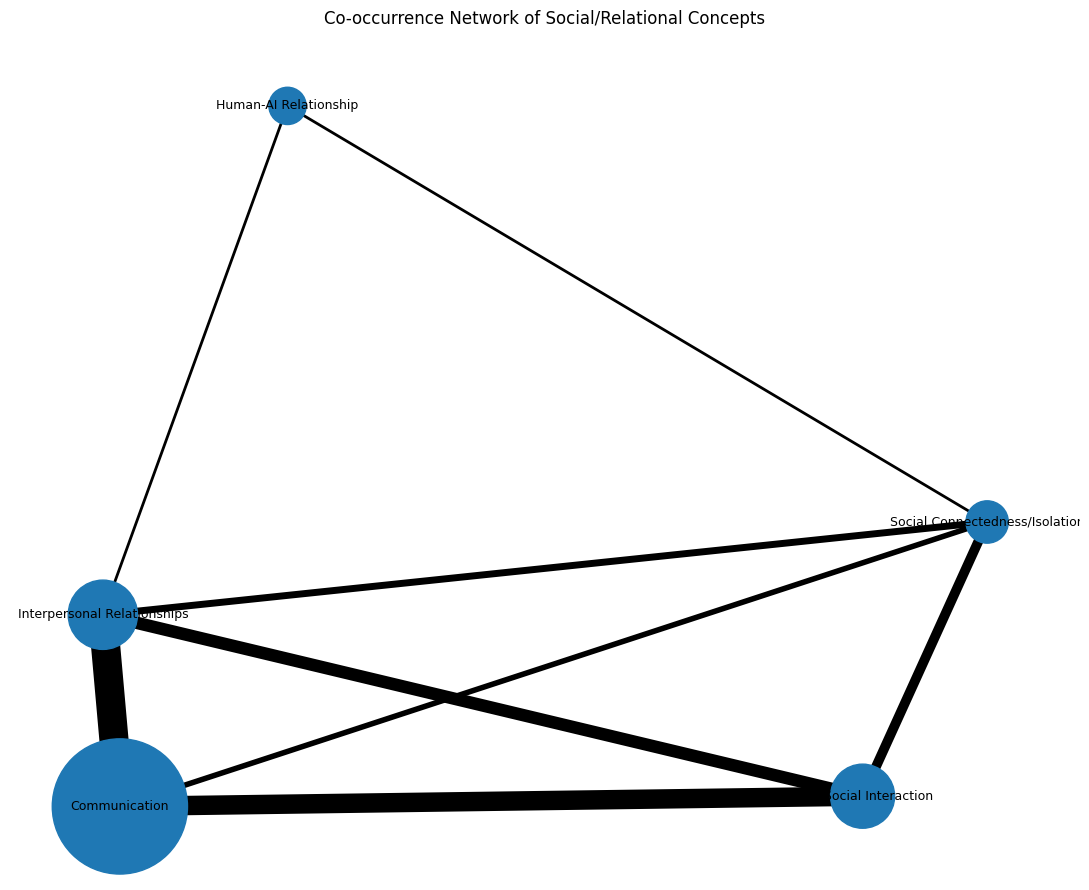

In [19]:
G = nx.Graph()

valid = [c for c in social_concepts if social_flag_matrix[c].sum() >= 3]

for c in valid:
    G.add_node(c, frequency=int(social_flag_matrix[c].sum()))

for i, c1 in enumerate(valid):
    for c2 in valid[i+1:]:
        co = int((social_flag_matrix[c1] & social_flag_matrix[c2]).sum())
        if co >= 2:
            G.add_edge(c1, c2, weight=co)

print("Social concept nodes:", G.number_of_nodes())
print("Social concept edges:", G.number_of_edges())

if G.number_of_nodes() > 0:
    plt.figure(figsize=(11,9))
    pos = nx.spring_layout(G, seed=42, k=1.4)

    nx.draw_networkx(
        G, pos,
        with_labels=True,
        node_size=[G.nodes[n]["frequency"]*30 for n in G.nodes],
        width=[G[u][v]["weight"] for u,v in G.edges],
        font_size=9
    )

    plt.title("Co-occurrence Network of Social/Relational Concepts")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("V2_social_concept_network.png", dpi=300, bbox_inches="tight")
    plt.show()


# 17. BERTopic social relevance

We compare each BERTopic cluster against the social query space.


In [20]:
topic_docs = (
    data[data["bertopic_topic"] != -1]
    .groupby("bertopic_topic")["_text"]
    .apply(lambda x: " ".join(x.head(50).tolist()))
)

topic_ids = topic_docs.index.tolist()
topic_embeddings = embedding_model.encode(
    topic_docs.tolist(),
    normalize_embeddings=True
)

topic_social_sim = cosine_similarity(
    query_embeddings,
    topic_embeddings
).max(axis=0)

social_topic_table = pd.DataFrame({
    "topic": topic_ids,
    "social_semantic_similarity": topic_social_sim
})

social_topic_table = (
    social_topic_table
    .merge(
        bertopic_info[["Topic","Count"]].rename(
            columns={"Topic":"topic","Count":"papers"}
        ),
        on="topic",
        how="left"
    )
    .merge(bertopic_words, on="topic", how="left")
    .sort_values("social_semantic_similarity", ascending=False)
)

display(social_topic_table.head(20))


,topic,social_semantic_similarity,papers,top_words
8,8,0.411255,130,"chatgpt, university, of, students, on, in, and..."
19,19,0.374781,31,"genai, motivation, learning, language, and, fl..."
18,18,0.353968,33,"plagiarism, academic, of, chatgpt, the, and, s..."
17,17,0.343436,45,"assessment, and, the, ai, of, in, to, genai, e..."
7,7,0.333687,134,"self, and, ai, learning, the, generative, of, ..."
2,2,0.332510,280,"language, the, and, english, of, in, learning,..."
5,5,0.332397,171,"intention, the, and, of, acceptance, perceived..."
3,3,0.314751,197,"chatgpt, the, of, and, use, students, to, in, ..."
6,6,0.300166,168,"creative, design, creativity, and, the, ai, in..."
13,13,0.290211,71,"thinking, critical, ai, and, the, students, of..."


# 18. Social attention over time

This is one of the most important analyses for the final paper.


,year,total_papers,lexical_social,semantic_top10,combined_social,mean_social_similarity,lexical_pct,combined_pct
0,2022,4,0,0,0,0.178148,0.000000,0.000000
1,2023,177,18,25,39,0.291743,10.169492,22.033898
2,2024,656,59,103,143,0.306551,8.993902,21.798780
3,2025,1615,157,170,287,0.294497,9.721362,17.770898
4,2026,2261,236,174,347,0.287076,10.437859,15.347192


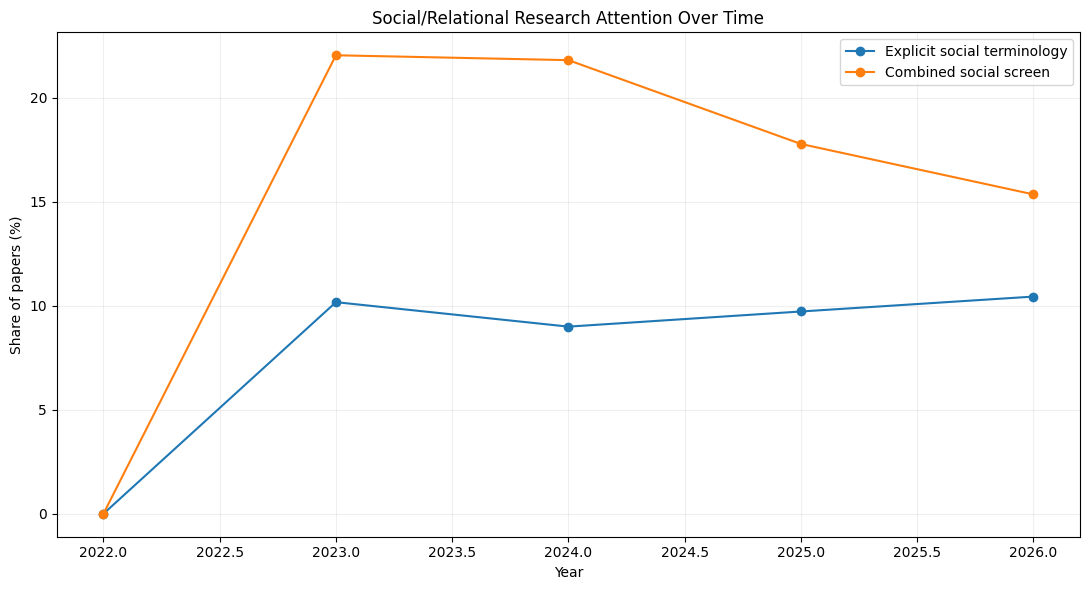

In [21]:
if year_col:
    temp = data[[year_col, "social_lexical_flag",
                 "social_max_similarity"]].copy()

    temp["semantic_top10"] = semantic_top10.astype(int).values
    temp["combined_social"] = combined_social.astype(int).values

    yearly_social = temp.groupby(year_col).agg(
        total_papers=(year_col,"size"),
        lexical_social=("social_lexical_flag","sum"),
        semantic_top10=("semantic_top10","sum"),
        combined_social=("combined_social","sum"),
        mean_social_similarity=("social_max_similarity","mean")
    ).reset_index()

    yearly_social["lexical_pct"] = (
        yearly_social["lexical_social"] /
        yearly_social["total_papers"] * 100
    )

    yearly_social["combined_pct"] = (
        yearly_social["combined_social"] /
        yearly_social["total_papers"] * 100
    )

    display(yearly_social)

    plt.figure(figsize=(11,6))
    plt.plot(
        yearly_social[year_col],
        yearly_social["lexical_pct"],
        marker="o",
        label="Explicit social terminology"
    )
    plt.plot(
        yearly_social[year_col],
        yearly_social["combined_pct"],
        marker="o",
        label="Combined social screen"
    )
    plt.xlabel("Year")
    plt.ylabel("Share of papers (%)")
    plt.title("Social/Relational Research Attention Over Time")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig("V2_social_gap_over_time.png", dpi=300, bbox_inches="tight")
    plt.show()


# 19. Emerging themes: growth in annual share

Raw counts are strongly affected by the explosive growth of the corpus. We therefore rank themes by change in their annual percentage share.


In [22]:
if year_col:
    growth_rows = []

    for concept in concepts:
        s = temporal[temporal["concept"] == concept].sort_values("year")

        # Compare earliest and latest available year, but report the values.
        if len(s) >= 2:
            first = s.iloc[0]
            last = s.iloc[-1]

            growth_rows.append({
                "concept": concept,
                "first_year": int(first["year"]),
                "first_share_pct": round(first["percentage"], 3),
                "last_year": int(last["year"]),
                "last_share_pct": round(last["percentage"], 3),
                "change_percentage_points": round(
                    last["percentage"] - first["percentage"], 3
                )
            })

    growth_table = pd.DataFrame(growth_rows).sort_values(
        "change_percentage_points", ascending=False
    )

    display(growth_table)


,concept,first_year,first_share_pct,last_year,last_share_pct,change_percentage_points
0,Education/Learning,2022,50.0,2026,82.353,32.353
7,Ethics/Integrity,2022,0.0,2026,28.041,28.041
1,Adoption/Acceptance,2022,0.0,2026,23.352,23.352
6,Psychological Well-being,2022,0.0,2026,23.308,23.308
4,AI Dependency,2022,0.0,2026,11.411,11.411
3,Creativity,2022,0.0,2026,11.411,11.411
10,Communication,2022,0.0,2026,6.855,6.855
9,Trust,2022,0.0,2026,6.192,6.192
5,Motivation/Engagement,2022,25.0,2026,29.854,4.854
8,Privacy,2022,0.0,2026,3.096,3.096


# 20. Optional: inspect the previously generated V1 social candidates

If `Social_Semantic_Candidates.csv` was uploaded, this section displays it for comparison. It is **not treated as final evidence**.


In [23]:
if social_candidate_files:
    v1_social = pd.read_csv(social_candidate_files[0], low_memory=False)
    print("V1 candidate file:", social_candidate_files[0])
    print("Rows:", len(v1_social))
    display(v1_social.head(30))
else:
    print("No V1 Social_Semantic_Candidates.csv uploaded; skipping comparison.")


No V1 Social_Semantic_Candidates.csv uploaded; skipping comparison.


# 21. Research-gap evidence table

This creates a concise table for manuscript development.


In [24]:
social_concept_summary = concept_table[
    concept_table["concept"].isin(social_concepts)
].copy()

social_concept_summary["gap_signal"] = pd.cut(
    social_concept_summary["percentage"],
    bins=[-np.inf, 1, 3, 10, np.inf],
    labels=["Very high", "High", "Moderate", "Low"]
)

display(
    social_concept_summary.sort_values("percentage")
)


,concept,papers,percentage,gap_signal
14,Human-AI Relationship,24,0.509,Very high
13,Social Connectedness/Isolation,31,0.658,Very high
11,Peer/Social Interaction,71,1.506,High
12,Interpersonal Relationships,83,1.761,High
10,Communication,316,6.705,Moderate


# 22. Export all results

The Excel workbook is the main output to upload back for interpretation.


In [25]:
# Core exports
data.to_csv("V2_Analyzed_OpenAlex_GenerativeAI_Students.csv", index=False)
concept_table.to_csv("V2_Concept_Frequency.csv", index=False)
dimension_table.to_csv("V2_Dimension_Coverage.csv", index=False)
tfidf_table.to_csv("V2_TFIDF_Terms.csv", index=False)
lda_topics.to_csv("V2_LDA_Topics.csv", index=False)
bertopic_info.to_csv("V2_BERTopic_Info.csv", index=False)
bertopic_words.to_csv("V2_BERTopic_Words.csv", index=False)
social_candidates_v2.to_csv("V2_Social_Semantic_Candidates.csv", index=False)
social_topic_table.to_csv("V2_Social_BERTopic_Topics.csv", index=False)
gap_test.to_csv("V2_Social_Gap_Test.csv", index=False)
social_concept_summary.to_csv("V2_Social_Concept_Summary.csv", index=False)

if year_col:
    annual.to_csv("V2_Annual_Publication_Growth.csv", index=False)
    temporal.to_csv("V2_Concept_Temporal.csv", index=False)
    yearly_social.to_csv("V2_Social_Temporal.csv", index=False)
    growth_table.to_csv("V2_Emerging_Theme_Growth.csv", index=False)

with pd.ExcelWriter(
    "Generative_AI_University_Students_Research_Analysis_V2_FINAL.xlsx",
    engine="openpyxl"
) as writer:
    audit.to_excel(writer, sheet_name="Dataset_Audit", index=False)
    concept_table.to_excel(writer, sheet_name="Concept_Frequency", index=False)
    dimension_table.to_excel(writer, sheet_name="Dimensions", index=False)
    tfidf_table.to_excel(writer, sheet_name="TFIDF", index=False)
    lda_topics.to_excel(writer, sheet_name="LDA_Topics", index=False)
    lda_distribution.to_frame("papers").to_excel(writer, sheet_name="LDA_Distribution")
    bertopic_info.to_excel(writer, sheet_name="BERTopic_Info", index=False)
    bertopic_words.to_excel(writer, sheet_name="BERTopic_Words", index=False)
    social_topic_table.to_excel(writer, sheet_name="Social_BERTopic", index=False)
    social_candidates_v2.to_excel(writer, sheet_name="Social_Candidates", index=False)
    gap_test.to_excel(writer, sheet_name="Social_Gap_Test", index=False)
    social_concept_summary.to_excel(writer, sheet_name="Social_Summary", index=False)

    if year_col:
        annual.to_excel(writer, sheet_name="Annual_Growth", index=False)
        temporal.to_excel(writer, sheet_name="Concept_Temporal", index=False)
        yearly_social.to_excel(writer, sheet_name="Social_Temporal", index=False)
        growth_table.to_excel(writer, sheet_name="Emerging_Growth", index=False)

print("FINAL V2 workbook created.")


FINAL V2 workbook created.


# 23. What to upload back for final research interpretation

Upload:

**`Generative_AI_University_Students_Research_Analysis_V2_FINAL.xlsx`**

I will then use the actual results to determine:

1. the final research gap,
2. whether the social/interpersonal novelty is defensible,
3. the best paper title,
4. research questions,
5. conceptual framework,
6. methodology,
7. hypotheses/propositions if appropriate,
8. key tables and figures,
9. and the target journal positioning.

### Do not make a novelty claim before this validation.
